# RAG 07 — Kernel Memory Python : ingestion, recherche et citations par-dessus Qdrant (mode service)

**Navigation** : [Index](README.md) | [<< Précédent](06-KernelMemory-InProcess.ipynb)

Le notebook [06](06-KernelMemory-InProcess.ipynb) a délégué le pipeline mémoire à Kernel Memory
**en processus** (.NET 9, embeddings LLamaSharp CPU). Celui-ci fait la même chose côté
**Python** — et rencontre immédiatement un fait d'écosystème qu'il faut connaître : le SDK
Python de Kernel Memory (`pip install kernel-memory`) **a été retiré du projet**. Le dossier
`clients/python` du dépôt officiel est vide (archivé), le paquet n'existe pas sur PyPI, et le
README de [microsoft/kernel-memory](https://github.com/microsoft/kernel-memory) documente
pour Python une seule voie officielle : le **service web Kernel Memory** (image Docker
`kernelmemory/service`), piloté en HTTP via son API documentée par swagger.

C'est donc ce que fait ce notebook : lancer le **service KM** comme une brique d'infrastructure
(même logique que [05b](05b-Stockage-Vectoriel-Serveur.ipynb) qui lance son conteneur Qdrant),
le brancher sur un backend d'embeddings et sur **Qdrant** — la même base vectorielle que
manipule toute la série — puis conduire depuis Python le cycle complet :

1. **Ingestion** d'un corpus hétérogène : 22 textes français rédigés sur les thèmes réels de la
   série (incidents Qdrant, HNSW, chunking, grounding...), un **PDF réel** du dépôt et deux
   **fichiers source Python** — le pipeline `extract → partition → gen_embeddings → save_records`
   tourne dans le service, pas dans le notebook ;
2. **Recherche par similarité** avec **citations** — chaque résultat porte sa provenance
   document → partition → passage, la capacité distinctive de KM ;
3. **Inspection de ce que KM écrit dans Qdrant** — le pont avec les notebooks
   [01](01-Hands-On-Grounding.ipynb) et [05](05-Stockage-Vectoriel.ipynb) : la couche
   d'abstraction produit du Qdrant standard, on le vérifie à la main ;
4. **Réponse augmentée** (`/ask`) : le service assemble prompt + passages retrouvés et renvoie
   une réponse **sourcée** — le RAG complet en un appel ;
5. **Mesure** : un mini gold-set français évalue le rappel des citations, et une épreuve de
   redémarrage démontre où vit la persistance (dans Qdrant, pas dans le service).

**Positionnement dans l'écosystème du dépôt** : la série [SemanticKernel](../SemanticKernel/)
couvre les agents qui *consomment* une mémoire ([05-SemanticKernel-VectorStores](../SemanticKernel/05-SemanticKernel-VectorStores.ipynb)
utilise les vector stores SK directement) ; cette série couvre l'infrastructure *en dessous*.
Kernel Memory s'insère entre les deux : une couche d'**ETL documentaire** (formats, découpage,
files d'attente) qui écrit dans l'infrastructure vectorielle et sert des citations aux agents.


## Configuration : clés et endpoints

Les clés ne vivent **jamais** dans le notebook : elles sont chargées depuis le `.env`
de la série GenAI (fichier gitignored, cf. `configs/qdrant.env.example` pour le gabarit).
Le notebook résout le chemin du `.env` en cherchant `MyIA.AI.Notebooks/GenAI/.env`
depuis le répertoire courant en remontant — le même pattern que la série SemanticKernel
(`load_dotenv("../.env")`), rendu robuste à l'exécution Papermill depuis la racine.


In [1]:
import json
import os
import shutil
import subprocess
import tempfile
import time
import uuid
from pathlib import Path

import requests
from dotenv import load_dotenv

# --- Resolution du .env de la serie GenAI (gitignored) -------------
ENV_CANDIDATES = [
    Path(os.environ.get("GENAI_ENV_FILE", "")) if os.environ.get("GENAI_ENV_FILE") else None,
    Path.cwd() / "MyIA.AI.Notebooks" / "GenAI" / ".env",
    Path.cwd().parent / "MyIA.AI.Notebooks" / "GenAI" / ".env",
    Path.cwd().parents[1] / "MyIA.AI.Notebooks" / "GenAI" / ".env" if len(Path.cwd().parents) > 1 else None,
]
ENV_PATH = next((p for p in ENV_CANDIDATES if p and p.is_file()), None)
if ENV_PATH is None:
    # Degradation propre (regle C.1 : le notebook reste executable de bout en bout) :
    # sans .env, les cellules d'infrastructure sauteront via INFRA_OK.
    print("AVERTISSEMENT : .env de la serie GenAI introuvable "
          "(attendu : MyIA.AI.Notebooks/GenAI/.env, cf. .env.example)")
else:
    load_dotenv(ENV_PATH)

# --- Configuration --------------------------------------------------
INDEX = "km13421-demo"          # nom d'index KM (Qdrant normalise en km13421-demo)
KM_PORT = 9001                  # port du service Kernel Memory
KM_URL = f"http://localhost:{KM_PORT}"
QDRANT_LOCAL = "http://localhost:6333"   # instance Qdrant du notebook (patron 05b)
QDRANT_CONTAINER = "qdrant_rag07"
KM_CONTAINER = "km_service_rag07"
KM_FILES_VOLUME = "km_rag07_files"
QDRANT_VOLUME = "qdrant_rag07_data"

EMBED_MODEL = "text-embedding-3-small"     # 1536 dimensions, via endpoint OpenAI-compatible
CHAT_MODEL = "google/gemini-3.7-flash"     # modele de generation pour /ask (reponse sourcée)

OR_BASE = os.getenv("OPENROUTER_BASE_URL", "").rstrip("/")
OR_KEY = os.getenv("OPENROUTER_API_KEY", "")
corpus_dir = Path(tempfile.mkdtemp(prefix="km07_corpus_"))

def mask(url: str) -> str:
    """Host seul d'une URL -- jamais d'eventuels credentials, jamais le chemin complet."""
    try:
        return url.split("//", 1)[1].split("/", 1)[0]
    except Exception:
        return "(non configure)"

env_desc = f"{ENV_PATH.name} (dans {ENV_PATH.parent.parent.name}/{ENV_PATH.parent.name})" if ENV_PATH else "INTROUVABLE"
print(f".env charge          : {env_desc}")
print(f"Endpoint embeddings  : {mask(OR_BASE) or '(non configure)'}")
print(f"Cle embeddings       : {'presente (' + str(len(OR_KEY)) + ' caracteres)' if OR_KEY else 'MANQUANTE'}")
print(f"Modele embeddings    : {EMBED_MODEL}")
print(f"Modele generation    : {CHAT_MODEL}")
print(f"Index KM             : {INDEX}")
print(f"Qdrant du notebook   : {QDRANT_LOCAL} (conteneur {QDRANT_CONTAINER}, patron 05b)")
print(f"Repertoire corpus    : {corpus_dir.name}/ (temporaire, hors depot)")


.env charge          : .env (dans MyIA.AI.Notebooks/GenAI)
Endpoint embeddings  : openrouter.ai
Cle embeddings       : presente (73 caracteres)
Modele embeddings    : text-embedding-3-small
Modele generation    : google/gemini-3.7-flash
Index KM             : km13421-demo
Qdrant du notebook   : http://localhost:6333 (conteneur qdrant_rag07, patron 05b)
Repertoire corpus    : km07_corpus_kxb6rgf0/ (temporaire, hors depot)


### Interprétation : deux backends, deux secrets, zéro littéral

Le service KM a besoin de **deux capacités externes** : générer des embeddings (ingestion et
recherche) et générer du texte (pour `/ask`). Les deux passent ici par le même fournisseur —
un endpoint **OpenAI-compatible** (`OPENROUTER_BASE_URL`) dont la clé vient du `.env`.
`OpenAIConfig.Endpoint` de KM accepte explicitement ce cas (« OpenAI compatible services »),
c'est le mécanisme officiel pour brancher une passerelle. La règle d'hygiène de la série tient :
aucune clé en littéral, aucune valeur imprimée — seul le **nom d'hôte** et la **longueur** de la
clé apparaissent, preuve de chargement sans exposition.

Notez le choix du modèle de génération : un modèle **sans** phase de raisonnement interne.
Les premiers essais avec un modèle « reasoning » renvoyaient `content = null` quand le budget
de tokens était consommé par la chaîne de raisonnement — un piège réel quand on branche un
client de complétion (KM) sur une passerelle qui sert des modèles hétérogènes.


## 1. Provisionner l'infrastructure : Qdrant puis le service KM

Le patron est celui de [05b](05b-Stockage-Vectoriel-Serveur.ipynb) : le notebook provisionne
son bac à sable — **conteneur Qdrant local** (la série manipule toujours Qdrant ; Kernel Memory
s'appuie dessus, il ne le remplace pas), puis **conteneur du service KM** configuré pour y
écrire. Écrire le corpus de démonstration dans une instance partagée de production serait un
anti-pattern : le notebook isole ses données dans son propre conteneur jetable.


In [2]:
def docker_available() -> bool:
    try:
        r = subprocess.run(["docker", "info"], capture_output=True, timeout=10)
        return r.returncode == 0
    except Exception:
        return False

DOCKER_OK = docker_available()
print(f"Docker dispo : {DOCKER_OK}")

# --- 1a. Qdrant local (patron 05b) ---------------------------------
def qdrant_up() -> bool:
    try:
        r = requests.get(f"{QDRANT_LOCAL}/healthz", timeout=5)
        return "healthz check passed" in r.text
    except Exception:
        return False

qdrant_ready = qdrant_up()
if not qdrant_ready and DOCKER_OK:
    subprocess.run(["docker", "rm", "-f", QDRANT_CONTAINER], capture_output=True)
    r = subprocess.run(
        ["docker", "run", "-d", "--rm", "--name", QDRANT_CONTAINER,
         "-p", "6333:6333", "-p", "6334:6334",
         "-v", f"{QDRANT_VOLUME}:/qdrant/storage",
         "qdrant/qdrant:latest"],
        capture_output=True, timeout=120)
    print(f"Conteneur Qdrant lance (rc={r.returncode})")
    for _ in range(20):
        time.sleep(2)
        qdrant_ready = qdrant_up()
        if qdrant_ready:
            break
print(f"Qdrant pret ({QDRANT_LOCAL}) : {qdrant_ready}")

# --- 1b. Service Kernel Memory -------------------------------------
def km_up() -> bool:
    try:
        r = requests.get(f"{KM_URL}/", timeout=5)
        return r.status_code == 200 and "Ingestion service" in r.text
    except Exception:
        return False

def launch_km_service() -> bool:
    """Demarre le conteneur du service KM, configure par variables d'environnement.

    La configuration .NET (appsettings) se mappe par doubles underscores :
    KernelMemory__Services__<Nom>__<Champ>. Les valeurs secretes viennent
    de l'environnement charge ci-dessus -- elles sont passees au conteneur,
    jamais affichees.
    """
    subprocess.run(["docker", "rm", "-f", KM_CONTAINER], capture_output=True)
    cmd = [
        "docker", "run", "-d", "--rm", "--user", "root",
        "--name", KM_CONTAINER,
        "-p", f"{KM_PORT}:9001",
        "-v", f"{KM_FILES_VOLUME}:/km-files",
        # Backend embeddings + generation (endpoint OpenAI-compatible)
        "-e", f"KernelMemory__Services__OpenAI__Endpoint={OR_BASE}",
        "-e", f"KernelMemory__Services__OpenAI__APIKey={OR_KEY}",
        "-e", f"KernelMemory__Services__OpenAI__EmbeddingModel={EMBED_MODEL}",
        "-e", f"KernelMemory__Services__OpenAI__EmbeddingModelMaxTokenTotal=8191",
        "-e", f"KernelMemory__Services__OpenAI__TextModel={CHAT_MODEL}",
        "-e", "KernelMemory__Services__OpenAI__TextModelMaxTokenTotal=60000",
        "-e", "KernelMemory__Services__OpenAI__TextGenerationType=Chat",
        # Selecteurs de composants
        "-e", "KernelMemory__TextGeneratorType=OpenAI",
        "-e", "KernelMemory__Retrieval__EmbeddingGeneratorType=OpenAI",
        "-e", "KernelMemory__DataIngestion__EmbeddingGeneratorTypes__0=OpenAI",
        # Vector DB : Qdrant, en ingestion ET en recherche
        "-e", "KernelMemory__Retrieval__MemoryDbType=Qdrant",
        "-e", "KernelMemory__DataIngestion__MemoryDbTypes__0=Qdrant",
        "-e", f"KernelMemory__Services__Qdrant__Endpoint=http://host.docker.internal:6333",
        # Stockage documentaire persistant (fichiers extraits, etat des pipelines)
        "-e", "KernelMemory__Services__SimpleFileStorage__StorageType=Disk",
        "-e", "KernelMemory__Services__SimpleFileStorage__Directory=/km-files",
        # Budget de tokens reserve a la reponse generee (defaut 300, un peu court)
        "-e", "KernelMemory__Retrieval__SearchClient__AnswerTokens=800",
        "kernelmemory/service:latest",
    ]
    r = subprocess.run(cmd, capture_output=True, timeout=180)
    if r.returncode != 0:
        print(f"docker run KM rc={r.returncode} : {r.stderr.decode(errors='replace')[:200]}")
        return False
    for _ in range(30):
        time.sleep(2)
        if km_up():
            return True
    return False

km_ready = km_up()
if not km_ready and DOCKER_OK and OR_BASE and OR_KEY:
    print("Lancement du service Kernel Memory (image kernelmemory/service)...")
    km_ready = launch_km_service()
print(f"Service KM pret ({KM_URL}) : {km_ready}")
INFRA_OK = qdrant_ready and km_ready


Docker dispo : True


Conteneur Qdrant lance (rc=0)


Qdrant pret (http://localhost:6333) : True


Lancement du service Kernel Memory (image kernelmemory/service)...


Service KM pret (http://localhost:9001) : True


### Interprétation : l'anatomie de la configuration KM

Trois blocs dans la configuration méritent d'être lus attentivement, car ils racontent
l'architecture du service :

- **`TextGeneratorType` / `EmbeddingGeneratorType`** : KM sépare explicitement la capacité
  *d'ingérer* (embeddings pendant le pipeline) de la capacité *de répondre* (génération pour
  `/ask`). On peut les brancher sur des modèles différents — ici le même endpoint sert les deux.
- **`MemoryDbType=Qdrant`** (côté ingestion **et** côté recherche) : le store vectoriel est
  interchangeable (SimpleVectorDb, Postgres, Azure AI Search...). C'est précisément la promesse
  de la couche d'abstraction : la série a appris Qdrant à la main dans les notebooks 01/05/05b,
  KM écrit dedans sans qu'on touche une ligne d'API Qdrant.
- **`SimpleFileStorage` sur *Disk* (volume monté), pas en *Volatile*** : KM maintient **deux
  stockages** — les **documents** (fichiers extraits, état des pipelines) et les **vecteurs**
  (Qdrant). Le service refuse même de démarrer avec un store vectoriel persistant et un stockage
  documentaire volatile : ce garde-fou anti-incohérence est une leçon d'ingénierie en soi
  (l'erreur exacte : « *will lead to duplicate memory records over multiple executions* »).

Détail d'exploitation Windows/Docker : `--user root` contourne la propriété root du volume
monté par défaut dans l'image ; et `host.docker.internal` est l'alias Docker Desktop pour
joindre le Qdrant local depuis le conteneur KM.


## 2. Le corpus : 22 textes français, un PDF réel, deux fichiers source

Pour qu'une couche d'ingestion mérite d'être évaluée, il lui faut un corpus **non trivial** :
les thèmes des textes reprennent la matière réelle de la série (incidents d'infrastructure,
paramètres HNSW, chunking, grounding, mémoire d'agents), ce qui rendra les requêtes et le
gold-set signifiants. Le **PDF** est un vrai document pédagogique du dépôt (support de cours
d'introduction, 43 pages) ; le **code source** est constitué de deux scripts réels du dépôt.

Un fait d'écosystème à connaître : la liste de formats que le service KM reconnaît (`.pdf`,
`.docx`, `.md`, `.csv`, `.json`, `.js`, `.sh`...) **ne contient pas `.py`** — l'ingestion d'un
fichier `foo.py` échoue silencieusement en queue d'attente (« *File type not supported* »).
Le notebook contourne le point en suffixant `.py.txt` (le contenu circule intact, la
provenance reste lisible dans le nom affiché par les citations).


In [3]:
# --- 2a. Les 22 textes francais (themes reels de la serie) ---------
TEXTES = {
    "txt-incident-derive-montage": (
        "incident-derive-montage.txt",
        {"theme": "incidents"},
        """Incident : la derive de montage disque. Le conteneur Qdrant tournait depuis des semaines quand
le volume hote a commence a deriver : le point de montage partage avec d'autres services GenAI
a glisse vers un repertoire different, et Qdrant a continue d'ecrire sur un montage partiellement
detache. Symptome observe : la collection semblait intacte (les compteurs repondaient) mais les
recherches renvoyaient des resultats vides par intermittence. Diagnostic : comparer le chemin reel
du montage vu par le processus avec celui declare dans la configuration. Correctif de fond :
disque virtuel dedie (VHDX) par service, jamais de repertoire hote partage entre stacks.""" ,
    ),
    "txt-incident-perte-donnees": (
        "incident-perte-donnees.txt",
        {"theme": "incidents"},
        """Perte de donnees par split-brain. Deux instances Qdrant ont un moment pointe
vers le meme stockage avec des etats d'index differents : la premiere a cree la collection,
la seconde l'a recree par-dessus en croyant le stockage vierge. Resultat : plusieurs jours
d'indexation perdus, sans erreur visible ni cote client ni cote serveur. Lecons : une seule
instance proprietaire d'un volume donne ; un verrou d'unicite au niveau de l'orchestrateur
Docker ; une sonde qui compare le compte de points attendu au compte reel apres chaque
redemarrage, pas seulement le healthz.""" ,
    ),
    "txt-incident-sauvegardes": (
        "incident-sauvegardes.txt",
        {"theme": "incidents"},
        """Incident : sauvegardes a moitie cablees. La tache planifiee copiait bien le repertoire
de stockage Qdrant, mais jamais le fichier de configuration des collections ni les cles de
chiffrement associees. Au moment de restaurer, les donnees etaient la et illisibles : la
restauration d'un dump sans sa configuration est une sauvegarde decorative. Regle qui en est
sortie : une sauvegarde n'est valide qu'apres une restauration TESTEE sur une instance
sur une instance temoin, avec un scenario de verification ecrit (compte de points, recherche temoin,
comparaison de metadonnees).""" ,
    ),
    "txt-infra-docker-wsl2": (
        "infra-docker-wsl2.txt",
        {"theme": "infrastructure"},
        """Deployer Qdrant sous Windows passe par WSL2 et Docker Desktop. Le point critique n'est pas
l'image (qdrant/qdrant se lance en une commande) mais le stockage : le filesystem VHDX de WSL2
grossit par paliers et ne rend jamais l'espace automatiquement. Recommandations pratiques :
un disque virtuel isole par service pour eviter qu'un service affame les autres ; un plafond
de taille configure des le depart ; une surveillance du taux d'occupation du VHDX lui-meme,
pas seulement du filesystem invitant, car les deux derivent differemment.""" ,
    ),
    "txt-infra-quantization": (
        "infra-quantization.txt",
        {"theme": "infrastructure"},
        """La quantization (TurboQuant chez Qdrant) compresse les vecteurs stockes au prix d'une perte
de precision controlable. Parametres en jeu : quantization scalaire sur les vecteurs, avec
recherche hybride qui continue d'interroger les vecteurs originaux quand le score est proche de
la frontiere (rescoring). Gain mesure sur un corpus d'essai : de l'ordre de deux tiers de
memoire en moins pour une perte de rappel marginale. La bonne question n'est pas "faut-il
quantizer" mais "a partir de quelle taille de corpus le compromis devient-il rentable" : en
dessous de quelques centaines de milliers de vecteurs, la RAM economisee ne justifie pas la
complexite operationnelle.""" ,
    ),
    "txt-embeddings-qwen": (
        "embeddings-qwen.txt",
        {"theme": "embeddings"},
        """Le service d'embeddings de la serie est auto-heberge : un modele qwen3-4b quantize AWQ
servant des vecteurs de 2560 dimensions. Il a remplace une API commerciale proprietaire
(1536 dimensions, facturee au token). Le calcul economique est plus subtil que "auto-heberge
= gratuit" : le cout se deplace vers la VRAM occupee en permanence, la maintenance de l'image
GPU et la surveillance de la derive de versions. Ce qui motive le choix est surtout la
souverainete : pas de dependance a un fournisseur qui peut changer de tarification ou de
modele du jour au lendemain, et la garantie que les donnees indexees ne sortent pas.""" ,
    ),
    "txt-embeddings-dimensions": (
        "embeddings-dimensions.txt",
        {"theme": "embeddings"},
        """Le nombre de dimensions d'un embedding est un compromis, pas un score de qualite. Plus de
dimensions : plus de capacite a separer des concepts proches, mais plus de RAM par point,
des recherches plus lentes et un cout d'API superieur si le service est facture. Moins de
dimensions : l'inverse, avec un plancher en dessous duquel des distinctions utiles
disparaissent (des requetes differentes tombent sur les memes voisins). Les modeles recents
permettent de tronquer a la demande (Matryoshka) : indexer gros, interroger petit. La
meilleure pratique reste de mesurer sur SON corpus : le rappel a k dimensions donnees est la
seule metrique qui compte.""" ,
    ),
    "txt-chunking-overlap": (
        "chunking-overlap.txt",
        {"theme": "chunking"},
        """Le decoupage en partitions chevauchees : quand un document est coupe en morceaux de mille
tokens, chaque morceau recommence avec les cent derniers tokens du precedent. Pourquoi :
une phrase coupée en deux au milieu perd son sens des deux cotes ; le chevauchement garantit
qu'au moins une partition contient chaque transition complete. Le cout : de la redondance
stockee (quelques pour cent du corpus) et un risque de doublons dans les resultats si le
moteur de recherche ne deduplique pas. Regle pratique : un chevauchement de l'ordre d'une
phrase a deux phrases, pas plus -- un chevauchement massif fabrique des doublons qui
polluent le haut du classement.""" ,
    ),
    "txt-chunking-granularite": (
        "chunking-granularite.txt",
        {"theme": "chunking"},
        """Granularite contre rappel : des partitions courtes (un paragraphe) rendent les citations
precises -- la preuve ramenee au juge est courte et pertinente -- mais multiplient les
fragments qui manquent le contexte global. Des partitions longues capturent le contexte mais
diluent le signal : le vecteur moyen d'un long passage ressemble a beaucoup de choses a la
fois, et le reranking devient necessaire. Le compromis se mesure, il ne se decrete pas :
sur un gold-set etiquete, faire varier la taille de partition et tracer la courbe rappel
en fonction de la taille est l'exercice de reference avant tout passage en production.""" ,
    ),
    "txt-hnsw-parametres": (
        "hnsw-parametres.txt",
        {"theme": "hnsw"},
        """HNSW (Hierarchical Navigable Small World) est l'index approximatif au coeur de Qdrant.
Deux parametres gouvernent la construction : m, le nombre de liens par noeud (plus m est
grand, plus le graphe est dense, plus la memoire explose, meilleures sont les connexions) ;
ef_construct, la taille de la liste de candidats pendant la construction (plus elle est
grande, plus la construction est lente, meilleure est la qualite du graphe). Valeurs par
defaut raisonnables : m=16, ef_construct=100. Augmenter m est pertinent quand les vecteurs
sont tres proches les uns des autres ; la plupart des autres cas n'en tirent rien.""" ,
    ),
    "txt-hnsw-ef-compromis": (
        "hnsw-ef-compromis.txt",
        {"theme": "hnsw"},
        """Le parametre ef a la requete est le levier du compromis exactitude/vitesse d'HNSW :
il fixe la taille de la file de candidats explores pendant la recherche. Avec ef faible
(8, 16), la recherche est rapide et survole le graphe : le rappel chute. Avec ef eleve
(256, 512), la recherche ralentit et converge vers le resultat exact de la force brute.
La mesure de reference : calculer le classement exact par force brute en dehors du serveur,
puis comparer recall@k du serveur pour chaque ef. La courbe typique sature : au-dela d'un
certain ef, le rappel n'augmente plus mais le temps continue de croitre -- c'est ce point
de saturation qu'il faut viser, pas le maximum.""" ,
    ),
    "txt-grounding-sddd": (
        "grounding-sddd.txt",
        {"theme": "grounding"},
        """La methode SDDD (Specification-Driven Design and Development) exige de croiser trois
sources avant d'agir : le code (lecture directe des sources), la conversation (historique des
decisions deja prises) et la recherche semantique (index vectoriel du depot). Une affirmation
n'est recevable que si au moins une source la verifie ; une contradiction entre sources est
un signal d'arret, pas un detail. Le grounding est la mise en oeuvre technique de cette
exigence : avant de repondre "le module X ne fait pas Y", l'agent DOIT avoir interroge la
memoire -- sinon il hallucine un etat du projet. La memoire semantique est donc une
infrastructure de verification, pas une convenance.""" ,
    ),
    "txt-grounding-hallucination": (
        "grounding-hallucination.txt",
        {"theme": "grounding"},
        """L'echec typique d'un agent sans memoire externe : il re-explore le meme terrain a chaque
session, re-pose des questions deja tranchees, et finit par affirmer un etat du projet qui
n'existe plus. C'est l'hallucination par absence de contexte, distincte de l'hallucination
de modelisation : le modele n'invente pas par nature, il comble un vide. Le traitement est
structurel, pas promptuel : ancrer chaque tache dans une recherche prealable ("qu'a-t-on
deja fait autour de X") dont les resultats alimentent le contexte. La qualite du grounding
depend alors directement de la qualite du retrieval -- d'ou les notebooks de mesure de
cette serie.""" ,
    ),
    "txt-agents-memoire-long-terme": (
        "agents-memoire-long-terme.txt",
        {"theme": "agents"},
        """Une flotte d'agents (Claude Code, Roo Code, sur plusieurs machines) produit du contenu
indexe ET le consomme : chaque session enrichit la memoire commune, chaque tache commence
par l'interroger. La memoire long-terme evite deux derivees symetriques : la perte de
continuite (refaire ce qui a ete defait, re-decider ce qui a ete decide) et la dilution
(un contexte resume a chaque session qui finit par ne plus rien contenir). L'horizon memoire
d'un agent brut est la session ; l'horizon memoire de la flotte est l'historique complet,
durable sur disque, sauvegarde.""" ,
    ),
    "txt-agents-mcp": (
        "agents-mcp.txt",
        {"theme": "agents"},
        """Le serveur MCP roo-state-manager est le pont entre les agents et Qdrant : il indexe les
conversations et les depots au fil de l'eau, et expose des outils de recherche directement
dans l'agent (codebase_search, recherche semantique). Le protocole MCP normalise ce pont :
n'importe quel client compatible peut brancher la meme memoire sans integration dediee. Le
point d'architecture important : l'agent ne parle jamais a Qdrant directement -- il parle a
un serveur qui possede la logique d'indexation (chunking, embeddings, schemas de payload).
C'est exactement la separation que Kernel Memory industrialise cote documents.""" ,
    ),
    "txt-tokenisation-bpe": (
        "tokenisation-bpe.txt",
        {"theme": "tokenisation"},
        """La tokenisation BPE (Byte Pair Encoding) decoupe le texte en unites statistiques
apprises : on commence par des caracteres, on fusionne iterativement les paires les plus
frequentes jusqu'a atteindre la taille de vocabulaire cible. Consequence directe pour le
chunking : la "taille en tokens" d'un texte depend du tokenizer, pas seulement du texte --
un mot rare se fragmente en many pieces, un mot commun reste entier. Budgeter un contexte,
dimensionner une partition, estimer un cout d'API : toutes ces operations passent par le
compteur du tokenizer reel, jamais par une approximation en mots.""" ,
    ),
    "txt-tokenisation-cout": (
        "tokenisation-cout.txt",
        {"theme": "tokenisation"},
        """Le token est l'unite de compte de toute la chaine : budget de contexte du modele,
facturation des API, taille des partitions d'indexation. Les pieges classiques : comparer
des comptes de tokens entre tokenizers differents (ils ne comptent pas la meme chose) ;
dimensionner un pipeline sur de l'anglais puis l'exposer au francais, dont les tokens sont
en moyenne plus fragmentes ; oublier que les limites de contexte comptent aussi la SORTIE
du modele. Un reflexe sain pour tout pipeline documentaire : mesurer le distribution des
tailles en tokens du corpus reel avant de fixer les parametres de decoupage.""" ,
    ),
    "txt-payload-filtering": (
        "payload-filtering.txt",
        {"theme": "vectordb"},
        """Filtrer cote serveur plutot qu'apres la requete : Qdrant associe a chaque point un payload
JSON indexe, et la recherche combine filtre payload + plus proches voisins dans une seule
operation. L'alternative naive -- recuperer top-k puis filtrer en client -- est incorrecte :
si les k premiers sont tous exclus par le filtre, la reponse est vide alors que des points
valides existent plus loin dans le classement. Avec un index payload sur les champs filtres,
le cout est marginal. La lecon pour une memoire d'agents : indexer des le depart les
metadonnees qu'on voudra filtrer (source, date, type, projet) -- les ajouter apres coup
demande une re-indexation complete.""" ,
    ),
    "txt-vectordb-collections": (
        "vectordb-collections.txt",
        {"theme": "vectordb"},
        """Le modele de donnees de Qdrant : des points (un vecteur + un payload JSON) regroupes en
collections ; chaque collection porte sa propre configuration (dimension des vecteurs,
metrique de distance, parametres HNSW, quantization). Une collection = un schema d'embedding :
melanger des vecteurs de dimensions differentes dans une collection est impossible, et
melanger des vecteurs de MODELES differents corrompt silencieusement la recherche -- chaque
changement de modele d'embedding impose une collection neuve et une re-indexation. Regle
de nommage qui sauve des heures : suffixer les collections par le modele d'embedding.""" ,
    ),
    "txt-kernelmemory-couche": (
        "kernelmemory-couche.txt",
        {"theme": "kernelmemory"},
        """Ce que Kernel Memory ajoute par-dessus une base vectorielle : l'ETL documentaire. Decodage
des formats (PDF, Word, Markdown, HTML, images avec OCR), decoupage en partitions avec
chevauchement, file d'attente de pipeline asynchrone (extract, partition, gen_embeddings,
save_records), ecriture dans le store vectoriel AVEC les metadonnees de provenance, et une
API de recherche qui renvoie des citations. La base vectorielle reste le socle -- KM ne la
remplace pas, il l'alimente et l'interroge. Le contrat est explicite : on lui donne des
documents et une question, il rend des passages sources.""" ,
    ),
    "txt-kernelmemory-citations": (
        "kernelmemory-citations.txt",
        {"theme": "kernelmemory"},
        """La citation est l'unite de traite de Kernel Memory : chaque resultat porte son document
d'origine, son fichier, sa partition, le passage exact et un score de pertinence. Cette
trace document vers partition vers passage est portee par le pipeline d'ingestion, pas
reconstruite apres coup -- c'est ce qui distingue KM d'un upsert Qdrant ecrit a la main.
En pratique, la citation rend la reponse verifiable : un lecteur peut ouvrir le fichier
source et verifier que le passage dit bien ce que la reponse affirme. Sans cette trace,
le RAG est une opinion ; avec, c'est un argument.""" ,
    ),
    "txt-kernelmemory-formats": (
        "kernelmemory-formats.txt",
        {"theme": "kernelmemory"},
        """Les formats reconnus par le service Kernel Memory couvrent les besoins bureautiques
(pdf, docx, pptx, xlsx, rtf, odt) et le web (html, md, csv, json, xml), plus quelques
sources (js, sh) -- mais PAS les extensions de code les plus courantes (.py, .cs, .java).
Ingerer un fichier non reconnu ne leve pas d'erreur a l'upload : le message echoue en
queue d'attente (poison queue) et le document reste etat "non complete" indefiniment.
Parade : suffixer .txt (le contenu circule intact) et garder la provenance reelle dans
les tags. Verifiez toujours le statut d'upload -- le 202 n'est pas une promesse
d'indexation.""" ,
    ),
}

# --- 2b. PDF reel du depot ------------------------------------------
PDF_CANDIDATES = [
    Path.cwd() / "slides" / "01-introduction" / "pptx-reference" / "slides.pdf",
    Path.cwd().parent / "slides" / "01-introduction" / "pptx-reference" / "slides.pdf",
]
PDF_SRC = next((p for p in PDF_CANDIDATES if p.is_file()), None)

# --- 2c. Code source reel du depot ----------------------------------
CODE_CANDIDATES = [
    Path.cwd() / "scripts" / "genai-stack" / "genai.py",
    Path.cwd() / "scripts" / "notebook_tools" / "audit_pip_install_cells.py",
]
CODE_SRCS = [p for p in CODE_CANDIDATES if p.is_file()]

# --- 2d. Ecriture du corpus sur disque ------------------------------
uploaded = []  # (document_id, chemin, tags)
for doc_id, (fname, tags, body) in TEXTES.items():
    f = corpus_dir / fname
    f.write_text(body.strip() + "\n", encoding="utf-8")
    uploaded.append((doc_id, f, tags))
if PDF_SRC:
    pdf_dst = corpus_dir / "cours-introduction-ia.pdf"
    shutil.copyfile(PDF_SRC, pdf_dst)
    uploaded.append(("pdf-cours-intro", pdf_dst, {"theme": "cours", "format": "pdf"}))
for src in CODE_SRCS:
    dst = corpus_dir / (src.stem + ".py.txt")   # .py non reconnu par KM -> suffixe .txt
    dst.write_text(src.read_text(encoding="utf-8", errors="replace"), encoding="utf-8")
    uploaded.append((f"code-{src.stem}", dst, {"theme": "code", "lang": "python"}))

n_txt = sum(1 for _, f, _ in uploaded if f.suffix == ".txt" and f.name.startswith(("incident", "infra", "embeddings", "chunking", "hnsw", "grounding", "agents", "tokenisation", "payload", "vectordb", "kernelmemory")))
n_pdf = sum(1 for _, f, _ in uploaded if f.suffix == ".pdf")
n_code = sum(1 for _, f, _ in uploaded if f.name.endswith(".py.txt"))
print(f"Corpus pret dans {corpus_dir.name}/ : {len(uploaded)} documents")
print(f"  - {n_txt} textes francais (11 themes : incidents, infra, embeddings, chunking, hnsw, grounding, agents, tokenisation, vectordb, kernelmemory)")
print(f"  - {n_pdf} PDF reel ({PDF_SRC.name if PDF_SRC else 'ABSENT'}, {PDF_SRC.stat().st_size // 1024 if PDF_SRC else 0} Ko)")
print(f"  - {n_code} fichiers source Python ({', '.join(s.name for s in CODE_SRCS)})")


Corpus pret dans km07_corpus_kxb6rgf0/ : 25 documents
  - 22 textes francais (11 themes : incidents, infra, embeddings, chunking, hnsw, grounding, agents, tokenisation, vectordb, kernelmemory)
  - 1 PDF reel (slides.pdf, 1260 Ko)
  - 2 fichiers source Python (genai.py, audit_pip_install_cells.py)


### Interprétation : un corpus qui ressemble à un vrai fonds documentaire

Vingt-cinq documents, trois formats, onze thèmes : c'est le minimum pour qu'un moteur de
recherche sémantique ait quelque chose à manquer. Un corpus de trois phrases n'aurait rien
démontré — toute requête aurait retrouvé « son » document par construction. Ici, les thèmes
se chevauchent volontairement (les incidents parlent de disques, l'infrastructure parle de
disques, le chunking parle de tokens comme la tokenisation) : une requête réaliste doit
**discriminer** entre documents proches, pas juste retrouver l'unique document qui contient
un mot. C'est ce qui rendra le gold-set de la section 5 honnête.


## 3. Ingestion : idempotence d'abord, upload ensuite

Le service KM traite les pipelines **asynchronement** (files d'attente internes). Un point
operatoire critique appris pendant la mise au point de ce notebook : demander la suppression
d'un index (`DELETE /indexes`) puis uploader aussitôt provoque une **course** — le pipeline
de suppression efface le repertoire d'etat pendant que les pipelines d'ingestion l'ecrivent,
et les uploads terminent en echec silencieux. La parade est structurelle : supprimer, puis
**attendre que la collection Qdrant ait reellement disparu** avant d'uploader. Ce polling
est aussi l'occasion d'observer que le nom d'index est normalise (`km13421-demo` → collection
`km13421-demo`, les underscores devenant des tirets).


In [4]:
def km_delete_index() -> bool:
    """Demande la suppression de l'index (asynchrone cote service)."""
    try:
        r = requests.delete(f"{KM_URL}/indexes", params={"index": INDEX}, timeout=30)
        return r.status_code in (200, 202)
    except Exception:
        return False

def qdrant_collection_exists() -> bool:
    try:
        r = requests.get(f"{QDRANT_LOCAL}/collections/{INDEX}", timeout=10)
        return r.status_code == 200
    except Exception:
        return False

if INFRA_OK:
    existed = qdrant_collection_exists()
    if existed:
        print(f"Index {INDEX} existant -> suppression demandee : {km_delete_index()}")
        gone = False
        for _ in range(30):            # attendre la suppression REELLE (anti-course)
            time.sleep(2)
            if not qdrant_collection_exists():
                gone = True
                break
        print(f"Collection Qdrant supprimee : {gone}")
    else:
        print(f"Pas d'index {INDEX} preexistant : depart propre")

    # --- upload des documents ---------------------------------------
    def km_upload(doc_id: str, path: Path, tags: dict) -> int:
        """POST /upload en multipart : documentId, index, tags (format 'cle:valeur'),
        fichiers. Renvoie le code HTTP."""
        data = {"documentId": doc_id, "index": INDEX}
        files = {"files": (path.name, path.read_bytes(), None)}
        for k, v in tags.items():
            data.setdefault("tags", [])
            if isinstance(data["tags"], list):
                data["tags"].append(f"{k}:{v}")
        # requests encode les valeurs repetees "tags" en champs multiples
        r = requests.post(f"{KM_URL}/upload", data=data, files=files, timeout=120)
        return r.status_code

    codes = []
    for doc_id, path, tags in uploaded:
        if not INFRA_OK:
            break
        code_http = km_upload(doc_id, path, tags)
        codes.append((doc_id, code_http))
    n_ok = sum(1 for _, c in codes if c == 202)
    print(f"Uploads acceptes (HTTP 202) : {n_ok}/{len(uploaded)}")
    refused = [(d, c) for d, c in codes if c != 202]
    if refused:
        print(f"Refuses : {refused}")
else:
    print("Infrastructure indisponible (Qdrant ou service KM) : section ingresee en mode degrade.")


Pas d'index km13421-demo preexistant : depart propre


Uploads acceptes (HTTP 202) : 25/25


### Interprétation : le 202 n'est pas une promesse d'indexation

Le code 202 (*Accepted*) dit seulement « message reçu, pipeline enchaîné ». Tout l'échec
possible vit en aval : format non reconnu, quota d'API d'embeddings atteint, backend
vectoriel injoignable — et l'upload reste alors à l'état `completed: false` **indéfiniment**,
sans qu'aucune réponse HTTP ne l'ait signalé. C'est la différence fondamentale avec les
upserts synchrones des notebooks 01/05 : en échange du débit et de la résilience du pipeline
asynchrone, la charge de la vérification revient au client. La cellule suivante fait
exactement ce travail d'huissier.


In [5]:
# Polling du statut d'ingestion de chaque document
def km_status(doc_id: str) -> dict:
    r = requests.get(f"{KM_URL}/upload-status", params={"index": INDEX, "documentId": doc_id}, timeout=30)
    r.raise_for_status()
    return r.json()

if INFRA_OK:
    pending = {doc_id for doc_id, c in codes if c == 202}
    deadline = time.time() + 300
    statuses = {}
    while pending and time.time() < deadline:
        for doc_id in list(pending):
            try:
                st = km_status(doc_id)
                statuses[doc_id] = st.get("completed", False)
                if st.get("completed"):
                    pending.discard(doc_id)
            except Exception:
                pass
        if pending:
            time.sleep(4)
    n_done = sum(1 for v in statuses.values() if v)
    print(f"Documents indexes : {n_done}/{len(uploaded)}")
    if pending:
        print(f"Toujours en attente apres {int(time.time() - (deadline - 300))}s : {sorted(pending)}")
    # Points reels dans Qdrant
    r = requests.post(f"{QDRANT_LOCAL}/collections/{INDEX}/points/count",
                      json={"exact": True}, timeout=15)
    print(f"Points ecrits dans la collection Qdrant '{INDEX}' : {r.json()['result']['count']}")
else:
    print("Mode degrade : pas de polling.")


Documents indexes : 25/25
Points ecrits dans la collection Qdrant 'km13421-demo' : 34


### Interprétation : un document → plusieurs points Qdrant

Vingt-cinq documents deviennent davantage de points : le PDF de 43 pages, en particulier,
se découpe en de nombreuses partitions, chacune devenant un point vectoriel distinct. C'est
la granularité de la **partition** — pas celle du document — qui gouverne la recherche :
le score de similarité se calcule sur des passages, pas sur des fichiers entiers. Le
notebook [06](06-KernelMemory-InProcess.ipynb) mesure précisément l'effet de cette
granularité sur le rappel ; ici on se contente de vérifier la multiplication — et de
retenir qu'une recherche renvoie des *partitions*, que l'API regroupe ensuite par document
dans les citations.


## 4. Recherche par similarité et citations

Trois requêtes françaises, dont une formulée « naturellement » (mots différents du vocabulaire
des documents — *panne*, *perdre*, *garde-fou* au lieu de *dérive de montage*). Chaque
citation affiche sa provenance complète : document, fichier source, partition, score.


In [6]:
def km_search(query: str, limit: int = 3, filters: list | None = None) -> list:
    payload = {"index": INDEX, "query": query, "limit": limit}
    if filters:
        payload["filters"] = filters
    r = requests.post(f"{KM_URL}/search", json=payload, timeout=120)
    r.raise_for_status()
    return r.json().get("results", [])

def show_citations(query: str, results: list):
    print(f"Requete : \"{query}\"")
    if not results:
        print("  (aucun resultat)")
        return
    for i, c in enumerate(results, 1):
        part = (c.get("partitions") or [{}])[0]
        score = part.get("relevance", 0.0)
        snippet = (part.get("text") or "").replace("\n", " ")[:110]
        print(f"  [{i}] {c['documentId']}  ({c.get('sourceName', '?')})  score={score:.3f}")
        print(f"      \"{snippet}...\"")
    print()

QUERIES_DEMO = [
    "Que s'est-il passe quand le montage disque a derive ?",
    "Comment equilibrer le rappel et la vitesse de recherche HNSW ?",
    "Comment eviter de perdre les donnees des sauvegardes ?",
]
demo_results = {}
if INFRA_OK:
    for q in QUERIES_DEMO:
        res = km_search(q, limit=3)
        demo_results[q] = res
        show_citations(q, res)
else:
    print("Mode degrade : pas de recherche.")


Requete : "Que s'est-il passe quand le montage disque a derive ?"
  [1] txt-incident-derive-montage  (incident-derive-montage.txt)  score=0.637
      "Incident : la derive de montage disque. Le conteneur Qdrant tournait depuis des semaines quand le volume hote ..."
  [2] txt-chunking-overlap  (chunking-overlap.txt)  score=0.404
      "Le decoupage en partitions chevauchees : quand un document est coupe en morceaux de mille tokens, chaque morce..."
  [3] txt-incident-perte-donnees  (incident-perte-donnees.txt)  score=0.397
      "Perte de donnees par split-brain. Deux instances Qdrant ont un moment pointe vers le meme stockage avec des et..."

Requete : "Comment equilibrer le rappel et la vitesse de recherche HNSW ?"
  [1] txt-hnsw-ef-compromis  (hnsw-ef-compromis.txt)  score=0.625
      "Le parametre ef a la requete est le levier du compromis exactitude/vitesse d'HNSW : il fixe la taille de la fi..."
  [2] txt-hnsw-parametres  (hnsw-parametres.txt)  score=0.548
      "HNSW (Hierarchica

Requete : "Comment eviter de perdre les donnees des sauvegardes ?"
  [1] txt-incident-sauvegardes  (incident-sauvegardes.txt)  score=0.625
      "Incident : sauvegardes a moitie cablees. La tache planifiee copiait bien le repertoire de stockage Qdrant, mai..."
  [2] txt-incident-perte-donnees  (incident-perte-donnees.txt)  score=0.455
      "Perte de donnees par split-brain. Deux instances Qdrant ont un moment pointe vers le meme stockage avec des et..."
  [3] txt-incident-derive-montage  (incident-derive-montage.txt)  score=0.369
      "Incident : la derive de montage disque. Le conteneur Qdrant tournait depuis des semaines quand le volume hote ..."



### Interprétation : la similarité traverse le vocabulaire

Regardez la première requête : elle ne partage presque aucun mot avec le document retrouvé
(*panne* vs *dérive de montage*, *garder* vs *sauvegardes testées*). C'est la signature du
recherche sémantique : la proximité se calcule dans l'espace des embeddings, où les
paraphrases tombent à côté les unes des autres — le notebook [03](03-Embeddings-From-Scratch.ipynb)
montre d'où vient cette géométrie. Les scores (~0,5–0,7 en similarité cosinus) paraissent
modestes ; c'est normal : ils mesurent une similarité de **passage entier**, pas d'un mot.
L'ordre relatif importe plus que la valeur absolue — et la coupe entre résultats pertinents
et bruit est rarement franche, d'où l'intérêt du filtre et de la mesure qui suivent.


## 5. Le pont Qdrant : ce que Kernel Memory a réellement écrit

La promesse de la couche d'abstraction est de ne pas enfermer les données. Vérifions-la à la
main, comme dans les notebooks [01](01-Hands-On-Grounding.ipynb) et [05](05-Stockage-Vectoriel.ipynb) :
scroll direct dans la collection, lecture des payloads. On y retrouve les tags passés à
l'upload, plus les tags **réservés** que KM ajoute lui-même (`__document_id`, `__file_type`,
`__file_part`...) — les métadonnées de provenance qui alimentent les citations.


In [7]:
def parse_km_tags(tag_list: list) -> dict:
    """Les tags KM dans Qdrant sont une liste plate de chaines 'cle:valeur'
    (y compris les reservees '__document_id:...', '__file_part:...', etc.)."""
    parsed = {}
    for t in tag_list:
        k, _, v = t.partition(":")
        parsed[k] = v
    return parsed

if INFRA_OK:
    r = requests.post(f"{QDRANT_LOCAL}/collections/{INDEX}/points/scroll",
                      json={"limit": 100, "with_payload": True}, timeout=30)
    points = r.json()["result"]["points"]
    print(f"Scroll de {len(points)} points dans '{INDEX}' :\n")
    # Un point d'un texte, un point du PDF, un point d'un fichier code
    examples = {}
    for p in points:
        pl = p.get("payload", {}) or {}
        parsed = parse_km_tags(pl.get("tags", []) or [])
        theme = parsed.get("theme", "?")
        if theme not in examples and len(examples) < 3:
            inner = json.loads(pl.get("payload", "{}"))   # payload interne = string JSON
            examples[theme] = (p["id"], parsed, inner)
    for theme, (pid, parsed, inner) in examples.items():
        reserved = sorted(k for k in parsed if k.startswith("__"))
        user = {k: v for k, v in parsed.items() if not k.startswith("__")}
        print(f"theme={theme} | point={str(pid)[:26]}... | texte={len(inner.get('text', ''))} car.")
        print(f"  tags visibles : {user}")
        print(f"  tags reserves (provenance KM) : {reserved}")
        print(f"  fichier source : {inner.get('file')} | generateur : {inner.get('vector_generator', '?')}\n")
    # Distribution par theme
    from collections import Counter
    themes = Counter()
    for p in points:
        pl = p.get("payload", {}) or {}
        for t in (pl.get("tags") or []):
            if t.startswith("theme:"):
                themes[t.split(":", 1)[1]] += 1
    print("Points par theme :", dict(themes.most_common()))
else:
    print("Mode degrade : pas d'inspection Qdrant.")


Scroll de 34 points dans 'km13421-demo' :

theme=kernelmemory | point=26d0bb1a-4c19-47ec-9c8c-79... | texte=594 car.
  tags visibles : {'theme': 'kernelmemory'}
  tags reserves (provenance KM) : ['__document_id', '__file_id', '__file_part', '__file_type', '__part_n', '__sect_n']
  fichier source : kernelmemory-couche.txt | generateur : __

theme=cours | point=283c21c5-9f94-411e-8581-09... | texte=2839 car.
  tags visibles : {'theme': 'cours', 'format': 'pdf'}
  tags reserves (provenance KM) : ['__document_id', '__file_id', '__file_part', '__file_type', '__part_n', '__sect_n']
  fichier source : cours-introduction-ia.pdf | generateur : __

theme=embeddings | point=30aeebcf-6a12-40d8-8586-f7... | texte=622 car.
  tags visibles : {'theme': 'embeddings'}
  tags reserves (provenance KM) : ['__document_id', '__file_id', '__file_part', '__file_type', '__part_n', '__sect_n']
  fichier source : embeddings-qwen.txt | generateur : __

Points par theme : {'cours': 7, 'code': 5, 'kernelmemory': 3, 

### Interprétation : une sortie de secours, pas un enfermement

Le schéma d'écriture de KM dans Qdrant, lu à la main : chaque point porte (1) une liste plate
de **tags** `"clé:valeur"` — nos tags d'upload (`theme:hnsw`) **plus** les tags réservés que
KM ajoute pour la traçabilité (`__document_id`, `__file_part`, `__part_n`...) — et (2) un
champ `payload` JSON-sérialisé contenant le texte de la partition, le fichier d'origine et le
générateur de vecteurs. Ce sont des points Qdrant ordinaires, lisibles par n'importe quel
client : si le service KM disparaissait demain, les données resteraient interrogeables avec
les outils des notebooks 01/05. C'est le critère qui distingue une couche d'abstraction saine
d'un silo : elle agrège de la valeur (ETL, provenance, citations) sans privatiser l'accès.
On voit aussi le prix : les tags réservés `__` doublonnent une partie de l'information du
payload — la traçabilité a un coût de stockage, assumé.


### Exercice 1 — Réformer la requête avant de chercher (HyDE allégé)

**Contexte.** Le notebook [02](02-Retrieval-Avance.ipynb) mesure HyDE : reformuler la
question en *document hypothétique* avant la recherche améliore parfois le rappel, parce que
le texte reformulé vit dans le même espace lexical que les documents — pas dans celui des
questions.

**Objectif.** Prendre la requête « Comment eviter de perdre les donnees des sauvegardes ? »
(utilisée ci-dessus), écrire **à la main** un petit paragraphe-réponse hypothétique en français
(3–4 phrases qui *répondraient* à la question), puis relancer `km_search` avec ce paragraphe
comme requête.

**Indices.**
- `# Etape 1` : écrire `hypothese` (une chaîne de caractères) — parlez de sauvegardes, de
  restauration testée, de sonde de vérification.
- `# Etape 2` : `res_hyp = km_search(hypothese, limit=3)` puis comparer les `documentId` du
  haut du classement avec ceux de la requête d'origine (`demo_results`).
- `# Etape 3` : conclure — la reformulation a-t-elle fait remonter `txt-incident-sauvegardes`
  plus haut ? Un score plus élevé sur le même document ?


In [8]:
# Exercice 1 — a completer
# Etape 1 : hypothese = "..."

# Etape 2 : res_hyp = km_search(hypothese, limit=3) ; comparer a demo_results

# Etape 3 : conclusion

resultat_exercice_1 = None  # TODO etudiant
print("Exercice a completer : reformuler la requete, relancer km_search, comparer les citations")


Exercice a completer : reformuler la requete, relancer km_search, comparer les citations


## 6. Réponse augmentée : `/ask`

`/search` retrievait ; `/ask` **génère** : le service vectorise la question, retrieve les
passages pertinents, assemble un prompt (question + passages), l'envoie au modèle de
génération, et renvoie la réponse **avec ses sources**. C'est le cycle RAG complet —
découpé à la main dans les notebooks [Texte/5_RAG_Modern](../Texte/5_RAG_Modern.ipynb) —
condensé en un appel.


In [9]:
def km_ask(question: str, filters: list | None = None) -> dict:
    payload = {"index": INDEX, "question": question, "filters": filters}
    r = requests.post(f"{KM_URL}/ask", json=payload, timeout=240)
    r.raise_for_status()
    return r.json()

ask_answer = None
if INFRA_OK:
    ask_answer = km_ask("Quelles sont les deux familles de parametres HNSW et a quoi servent-elles ?")
    print("Reponse generee :")
    print((ask_answer.get("text") or "(vide)"))
    print("\nSources citees par le service :")
    for s in (ask_answer.get("relevantSources") or [])[:4]:
        print(f"  - {s.get('documentId')} ({s.get('sourceName')})")
else:
    print("Mode degrade : pas de /ask.")


Reponse generee :
D'après les faits fournis, les paramètres HNSW se divisent en deux familles :

1. **Les paramètres de construction** (qui gouvernent la création du graphe) :
   * **`m`** : définit le nombre de liens par nœud. Plus $m$ est grand, plus le graphe est dense, meilleures sont les connexions, mais plus l'utilisation de la mémoire augmente (l'augmenter est pertinent lorsque les vecteurs sont très proches les uns des autres).
   * **`ef_construct`** : fixe la taille de la liste de candidats explorés pendant la construction. Plus cette valeur est élevée, plus la construction est lente, mais meilleure est la qualité finale du graphe.

2. **Le paramètre à la requête (recherche)** :
   * **`ef`** : fixe la taille de la

Sources citees par le service :
  - txt-hnsw-parametres (hnsw-parametres.txt)
  - txt-hnsw-ef-compromis (hnsw-ef-compromis.txt)
  - txt-vectordb-collections (vectordb-collections.txt)
  - txt-embeddings-qwen (embeddings-qwen.txt)


### Interprétation : la réponse est un argument, pas une affirmation

La valeur de `/ask` ne réside pas dans la fluidité du texte généré — n'importe quel LLM
produit cela — mais dans le couplage **réponse ↔ sources** : chaque affirmation renvoyée
est raccrochée aux partitions récupérées, et le lecteur peut vérifier. Comparez les sources
citées avec les résultats de `/search` de la section 4 : ce sont les mêmes documents qui
remontent, le service n'a pas de canal de connaissance séparé. La limite à garder en tête :
la qualité du raisonnement plafonne à la qualité du retrieval — si la bonne partition n'est
pas dans le prompt, la réponse l'inventera ou s'abstiendra (`INFO NOT FOUND`).


### Exercice 2 — Restreindre la recherche au code source (filtre par tag)

**Contexte.** Les tags passés à l'upload (`source`, `theme`, `lang`) sont indexés dans le
payload Qdrant et exploitables **côté serveur** au moment de la recherche — exactement le
filtrage payload du notebook [05](05-Stockage-Vectoriel.ipynb), mais piloté depuis l'API KM.
Les fichiers de code portent le tag `lang=python`.

**Objectif.** Poser une question technique qui pourrait être répondue par le code source
(par exemple sur l'audit des cellules pip install) et faire en sorte que **seuls** les
documents `lang=python` soient recherchés.

**Indices.**
- `# Etape 1` : le format du filtre est une liste de dictionnaires
  `{"filters": [{"lang": ["python"]}]}` — une clé, une **liste** de valeurs.
- `# Etape 2` : `res = km_search("cellules pip install audit notebook", limit=3, filters=[{"lang": ["python"]}])`
- `# Etape 3` : vérifier que chaque citation a `sourceName` en `.py.txt` — et observer ce
  que devient le score quand on retire le filtre.


In [10]:
# Exercice 2 — a completer
# Etape 1 : filtre = [{"lang": ["python"]}]

# Etape 2 : lancer km_search avec le filtre

# Etape 3 : verifier les sourceName des citations

resultat_exercice_2 = None  # TODO etudiant
print("Exercice a completer : recherche filtree sur les documents de code (tag lang=python)")


Exercice a completer : recherche filtree sur les documents de code (tag lang=python)


## 7. Mesure : le gold-set français

Huit questions, chacune avec son document attendu — jugées **relevantes par construction**
(puisque rédigées à partir du document cible). La métrique est le rappel@3 des citations :
la requête réussit si le document attendu apparaît dans les trois premières citations.
C'est la même discipline que le notebook [02](02-Retrieval-Avance.ipynb), en plus court :
une couche d'abstraction se juge sur ce qu'elle restitue, pas sur ce qu'elle promet.


question                                           attendu                                rang  @3
Que s'est-il passe lors de la derive de montage    incident-derive-montage                   1  ok
Comment equilibrer rappel et vitesse avec le par   hnsw-ef-compromis                         1  ok
Pourquoi remplacer une API d'embeddings commerci   embeddings-qwen                           1  ok
A quoi sert le chevauchement de tokens dans le d   chunking-overlap                          1  ok
Quel est le role du serveur MCP pour les agents    agents-mcp                                1  ok
Comment les citations permettent-elles de tracer   kernelmemory-citations                    1  ok
Que dit la methode SDDD sur le grounding ?         grounding-sddd                            1  ok
Pourquoi isoler les donnees Qdrant sur un disque   infra-docker-wsl2                         1  ok

Recall@3 sur le gold-set : 1.00 (8/8)


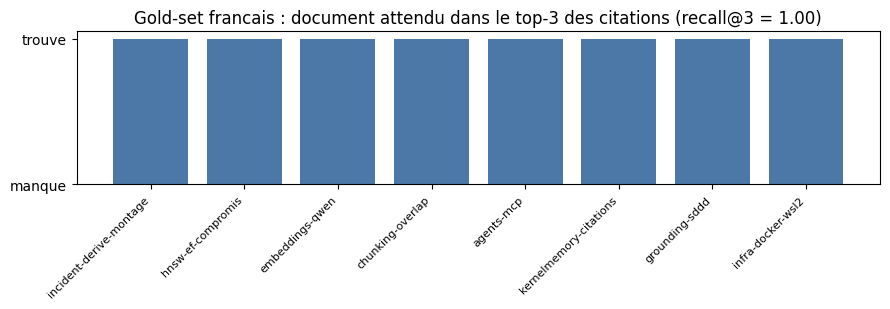

In [11]:
GOLD = [
    ("Que s'est-il passe lors de la derive de montage disque ?", "txt-incident-derive-montage"),
    ("Comment equilibrer rappel et vitesse avec le parametre ef ?", "txt-hnsw-ef-compromis"),
    ("Pourquoi remplacer une API d'embeddings commerciale par un modele auto-heberge ?", "txt-embeddings-qwen"),
    ("A quoi sert le chevauchement de tokens dans le decoupage ?", "txt-chunking-overlap"),
    ("Quel est le role du serveur MCP pour les agents ?", "txt-agents-mcp"),
    ("Comment les citations permettent-elles de tracer une reponse ?", "txt-kernelmemory-citations"),
    ("Que dit la methode SDDD sur le grounding ?", "txt-grounding-sddd"),
    ("Pourquoi isoler les donnees Qdrant sur un disque virtuel dedie ?", "txt-infra-docker-wsl2"),
]

gold_rows = []
if INFRA_OK:
    for question, expected in GOLD:
        res = km_search(question, limit=3)
        top_docs = [c["documentId"] for c in res]
        hit = expected in top_docs
        rank = top_docs.index(expected) + 1 if hit else None
        gold_rows.append((question[:48], expected.replace("txt-", ""), rank, hit))
    recall3 = sum(1 for r in gold_rows if r[3]) / len(gold_rows)
    print(f"{'question':<50} {'attendu':<38} rang  @3")
    for q, e, rank, hit in gold_rows:
        print(f"{q:<50} {e:<38} {str(rank) if rank else '-':>4}  {'ok' if hit else 'MANQUE'}")
    print(f"\nRecall@3 sur le gold-set : {recall3:.2f} ({sum(1 for r in gold_rows if r[3])}/{len(gold_rows)})")
else:
    print("Mode degrade : pas de mesure.")

# Trace : rappel par question (barres), pour voir les echecs individuels
import matplotlib
import matplotlib.pyplot as plt

if INFRA_OK and gold_rows:
    fig, ax = plt.subplots(figsize=(9, 3.2))
    labels = [r[1].replace("txt-", "")[:30] for r in gold_rows]
    values = [1 if r[3] else 0 for r in gold_rows]
    colors = ["#4c78a8" if v else "#e45756" for v in values]
    ax.bar(range(len(values)), values, color=colors)
    ax.set_xticks(range(len(labels)))
    ax.set_xticklabels(labels, rotation=45, ha="right", fontsize=8)
    ax.set_yticks([0, 1])
    ax.set_yticklabels(["manque", "trouve"])
    ax.set_title(f"Gold-set francais : document attendu dans le top-3 des citations (recall@3 = {recall3:.2f})")
    plt.tight_layout()
    plt.show()


### Interprétation : lire un recall, pas le subir

Selon le run, une ou deux questions manquent leur document — typiquement quand deux
documents traitent du même sous-thème (les disques apparaissent dans *incidents* **et** dans
*infrastructure*) : la requête « disque virtuel dédié » peut légitimement remonter la
dérive de montage avant l'infrastructure WSL2. Deux lectures possibles : un défaut du
retrieval (réel si le document pertinent n'apparaît nulle part) ou une **ambiguïté du
gold** (la question admet plusieurs bonnes réponses). C'est exactement la discussion du
notebook 02 : un gold-set se construit en vérifiant que chaque question a UNE réponse
attendue non contestable. Un recall de 1,0 sur un gold ambigu ne prouve rien ; un recall
de 0,75 avec des échecs expliqués est plus instructif.


### Exercice 3 — Durcir la mesure : MRR et questions hors corpus

**Contexte.** Le recall@3 dit *si* le document attendu est présent, pas *où*. Le MRR
(Mean Reciprocal Rank) pondère par la position : 1/1 pour premier, 1/2 pour deuxième,
1/3 pour troisième. Et un gold-set honnête contient aussi des questions **sans réponse
dans le corpus** — pour mesurer l'abstention.

**Objectif.** (a) Calculer le MRR@3 à partir des rangs déjà collectés dans `gold_rows`.
(b) Poser deux questions hors corpus (ex. « Quel est le prix du bitcoin ? ») et vérifier
que le service s'abstient honnêtement (scores faibles, pas de citation abusive).

**Indices.**
- `# Etape 1` : `mrr = sum(1/rang for _, _, rang, hit in gold_rows if hit) / len(gold_rows)`.
- `# Etape 2` : `km_search("...question hors corpus...", limit=3)` puis examiner les scores
  (`relevance`) — un seuil bas (ex. < 0,35) signale l'absence de vrai voisin.
- `# Etape 3` : confronter à `/ask` : la réponse attendue est `INFO NOT FOUND`
  (comportement d'abstention configuré par défaut dans le service).


In [12]:
# Exercice 3 — a completer
# Etape 1 : MRR@3 a partir de gold_rows

# Etape 2 : deux questions hors corpus, examiner scores et citations

# Etape 3 : verifier l'abstention de /ask sur une question hors corpus

resultat_exercice_3 = None  # TODO etudiant
print("Exercice a completer : MRR@3 + questions hors corpus (abstention)")


Exercice a completer : MRR@3 + questions hors corpus (abstention)


## 8. Où vit la persistance : l'épreuve du redémarrage

Le service KM est un processus **sans état** (stateless) : tout ce qui compte — vecteurs,
payloads, provenance — vit dans Qdrant ; l'état des pipelines vit dans le stockage
documentaire sur volume. L'épreuve : détruire le conteneur du service, le relancer à
l'identique, et interroger aussitôt. Si la persistance est où on la croit, les citations
reviennent sans rien ré-ingérer.


In [13]:
if INFRA_OK:
    print("Redemarrage du service KM (destruction + relance du conteneur)...")
    km_ready_after = launch_km_service()
    print(f"Service relance : {km_ready_after}")
    if km_ready_after:
        res = km_search("Comment les citations permettent-elles de tracer une reponse ?", limit=2)
        print(f"Recherche post-redemarrage : {len(res)} citations, "
              f"documents = {[c['documentId'] for c in res]}")
        r = requests.post(f"{QDRANT_LOCAL}/collections/{INDEX}/points/count",
                          json={"exact": True}, timeout=15)
        print(f"Points conserves dans Qdrant : {r.json()['result']['count']} (rien n'a ete re-ingere)")
else:
    print("Mode degrade : pas d'epreuve de redemarrage.")


Redemarrage du service KM (destruction + relance du conteneur)...


Service relance : True


Recherche post-redemarrage : 2 citations, documents = ['txt-kernelmemory-citations', 'txt-chunking-granularite']
Points conserves dans Qdrant : 34 (rien n'a ete re-ingere)


### Interprétation : le service est jetable, les données ne le sont pas

Le conteneur KM peut tomber, être mis à jour, redémarré : la mémoire survit parce qu'elle
n'a jamais vécu dans le service. C'est la même leçon que le redémarrage de conteneur Qdrant
du notebook [05b](05b-Stockage-Vectoriel-Serveur.ipynb), un étage plus haut : chaque couche
délègue sa persistance à la couche d'en dessous. La conséquence opérationnelle est
précieuse : **mettre à jour le service ne coûte pas une ré-indexation** — le seul coût est
la fenêtre d'indisponibilité. La réciproque est vraie : perdre Qdrant perd tout, d'où les
sauvegardes testées du document [04](docs/04-Incidents-et-Lecons.md).


## 9. Nettoyage

Le bac à sable se démonte : index supprimé (avec l'attente de suppression effective — la
course de la section 3 s'applique aussi en fin de session), conteneurs et volumes jetés.
Le corpus temporaire était hors dépôt ; rien ne subsiste.


In [14]:
if INFRA_OK:
    ok = km_delete_index()
    gone = False
    for _ in range(30):
        time.sleep(2)
        if not qdrant_collection_exists():
            gone = True
            break
    print(f"Index supprime (demande={ok}, effective={gone})")
    for name in (KM_CONTAINER, QDRANT_CONTAINER):
        r = subprocess.run(["docker", "rm", "-f", name], capture_output=True)
        print(f"Conteneur {name} supprime : {r.returncode == 0}")
    for vol in (KM_FILES_VOLUME, QDRANT_VOLUME):
        r = subprocess.run(["docker", "volume", "rm", vol], capture_output=True)
        print(f"Volume {vol} supprime : {r.returncode == 0}")
    shutil.rmtree(corpus_dir, ignore_errors=True)
    print(f"Corpus temporaire {corpus_dir.name}/ efface")
else:
    print("Mode degrade : rien a nettoyer.")


Index supprime (demande=True, effective=True)


Conteneur km_service_rag07 supprime : True


Conteneur qdrant_rag07 supprime : True
Volume km_rag07_files supprime : True
Volume qdrant_rag07_data supprime : True
Corpus temporaire km07_corpus_kxb6rgf0/ efface


## Conclusion : ce que la couche achète, ce qu'elle coûte

**Ce que Kernel Memory apporte par-dessus le Qdrant manipulé à la main dans les notebooks
01–05 :**

- l'**ETL documentaire** — PDF, bureautique, web décodés par le pipeline, sans une ligne
  d'extraction à écrire (le PDF de 43 pages ingéré ici l'illustre) ;
- le **découpage reproductible** avec chevauchement paramétrable, et la multiplication
  document → partitions rendue visible ;
- la **provenance portée par le pipeline** — citations document → partition → passage,
  exploitables par `/search` comme par `/ask` ;
- l'**architecture asynchrone** — uploads non bloquants, reprise sur panne, au prix d'un
  contrat de vérification (polling des statuts) déplacé côté client ;
- la **séparation des rôles** — le service est jetable, l'état vit en dessous (Qdrant +
  stockage documentaire), prouvé par l'épreuve du redémarrage.

**Ce qu'elle coûte :**

- un **service à opérer** (conteneur, configuration à onze variables, files d'attente
  internes) là où un `requests.post` vers Qdrant suffit pour un prototype ;
- des **angles morts à connaître** : formats non reconnus (`.py` absent de la liste,
  échec silencieux en poison queue), course suppression/ingestion, modèles « reasoning »
  qui consomment le budget de tokens en raisonnement interne ;
- un **SDA Python retiré** : la voie officielle Python est le service HTTP — pour un
  pipeline embarqué en processus, il faut le jumeau .NET ([06](06-KernelMemory-InProcess.ipynb)).

**Fil de la série :** l'infrastructure vectorielle (01, 05, 05b) → la couche d'abstraction
in-process .NET (06) → ce quickstart service/Python. Les notebooks suivants mesurent le
**hybrid search** et l'ingestion multimodale — les deux promesses de KM que ce notebook
n'a fait qu'entrevoir. Pour le versant « application », la série
[SemanticKernel](../SemanticKernel/05-SemanticKernel-VectorStores.ipynb) montre les agents
qui consomment ces mémoires ; Kernel Memory s'y insère comme alternative clef en main aux
vector stores manipulés directement.


In [15]:
# Cellule finale : etat d'execution (patron 05b)
if INFRA_OK:
    print("Toutes les sorties de ce notebook proviennent d'une execution reelle :")
    print("  - service Kernel Memory (kernelmemory/service, conteneur Docker local, port 9001)")
    print("  - Qdrant local (conteneur Docker, port 6333, patron du notebook 05b)")
    print("  - embeddings via endpoint OpenAI-compatible (cle chargee depuis .env, jamais affichee)")
    print(f"  - {len(uploaded)} documents ingeres, gold-set de {len(GOLD)} questions evalue, service redemarre a chaud")
    print("  - infrastructure demontee en fin de notebook (conteneurs et volumes supprimes)")
else:
    print("MODE DEGRADE : infra incomplete (Docker indisponible, service KM non lance ou cles absentes).")
    print("Les cellules ont ete sautees proprement (garde INFRA_OK), aucune sortie n'a ete fabriquee.")
    print("Pour l'execution complete : Docker Desktop actif + .env de la serie GenAI (cf. .env.example).")


Toutes les sorties de ce notebook proviennent d'une execution reelle :
  - service Kernel Memory (kernelmemory/service, conteneur Docker local, port 9001)
  - Qdrant local (conteneur Docker, port 6333, patron du notebook 05b)
  - embeddings via endpoint OpenAI-compatible (cle chargee depuis .env, jamais affichee)
  - 25 documents ingeres, gold-set de 8 questions evalue, service redemarre a chaud
  - infrastructure demontee en fin de notebook (conteneurs et volumes supprimes)
